In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import os
import sys
import pickle
import math
import matplotlib

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import func_optimize as fo
from neurolib.utils import costFunctions as cost


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2    

not here
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
readpath = '..' + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

with open(readpath + os.sep + 'bi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc_granular = load_array[0]
ext_inh_granular = load_array[1]

with open(readpath + os.sep + 'boundary_bi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_exc_granular = load_array[0]
boundary_inh_granular = load_array[1]

grid_resolution = layout.grid_resolution
grid_resolution_granular = layout.grid_resolution_granular

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

facecolor_ = '#EAEAEA'
#facecolor_ = 'white'

In [3]:
readpath = '..' + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

In [4]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]

def readcase(case_):
    
    global ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low 
    global d_e, d_i, d_total
    global cost_p_x, cost_p_y, cost_s_x, cost_s_y, cost_e_x, cost_e_y
    
    readpath = '..' + os.sep + 'data_final' + os.sep
    
    data_array = data.read_data_1(aln, readpath, case_)
    ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low = data_array
    
    opt_control = [None] * len(ind_)
    opt_state = [None] * len(ind_)
    
    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_state = control_data[3]
        
    d_e = [None] * len(ind_)
    d_i = [None] * len(ind_)
    d_total = [None] * len(ind_)
    
    cost_p_x = [None] * len(ext_exc)
    cost_p_y = [None] * len(ext_exc)
    cost_s_x = [None] * len(ext_exc)
    cost_e_x = [None] * len(ext_exc)
    cost_s_y = [None] * len(ext_exc)
    cost_e_y = [None] * len(ext_exc)
    
    for i in ind_:
        
        if type(opt_control[i]) == type(None):
            continue
    
        if case_ in ['1', '2']:
            d_e[i] = data.dist_right(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_low(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_up_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                                   grid_resolution_granular)
        else:
            d_e[i] = data.dist_left(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_up(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_down_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                               grid_resolution_granular)

        cost_p_x[i] = cost_node[i][0][0][0]
        cost_s_x[i] = cost_node[i][2][0][0]
        cost_e_x[i] = cost_node[i][1][0][0]
        cost_p_y[i] = cost_node[i][0][0][1]
        cost_s_y[i] = cost_node[i][2][0][1]
        cost_e_y[i] = cost_node[i][1][0][1]

case =  ..\data_final 1
case =  ..\data_final\ 1


__main__:124: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


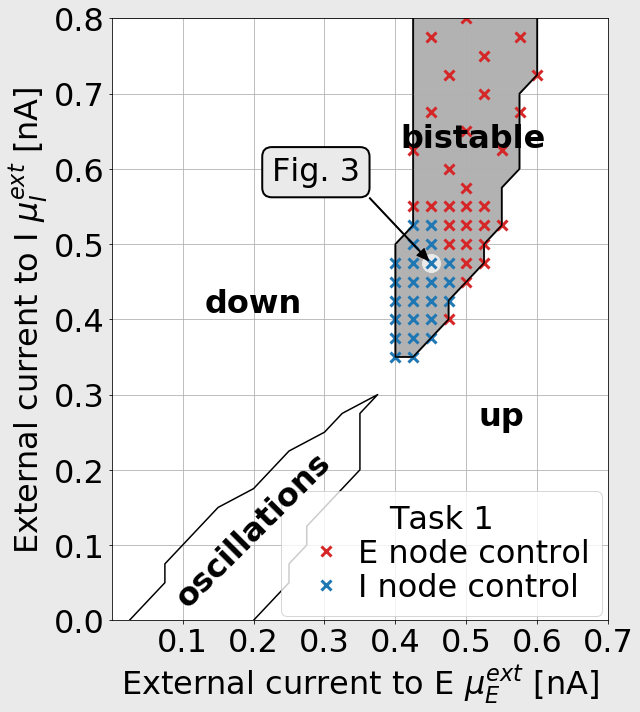

In [5]:
##### LOAD BOUNDARIES
with open('boundary_bi.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_bi_exc = load_array[0]
boundary_bi_inh = load_array[1]

with open('bi.pickle','rb') as file:
    load_array= pickle.load(file)
bi_exc = load_array[0]
bi_inh = load_array[1]

with open('boundary_LC.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_exc = load_array[0]
boundary_LC_inh = load_array[1]

with open('boundary_LCbi.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_up_exc = load_array[0]
boundary_LC_up_inh = load_array[1]


fontsize_ = 32

fig1, ax = plt.subplots(constrained_layout=True, figsize = (9,10), facecolor=facecolor_)
ax.set_ylim(0., .8)
ax.set_xlim(0., .7)
ax.set_xticks(np.arange(0.1, 0.8, 0.1))

vertices = np.zeros(( len(boundary_bi_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_bi_exc[i]
    vertices[i,1] = boundary_bi_inh[i]
path = mpath.Path(vertices)

patch = patches.PathPatch(path, facecolor='grey', alpha=0.6, lw=2)
ax.add_patch(patch)


readcase('1')
cost_index = np.zeros(( len(ext_exc), 4))
    
ind_x = 0
ind_y = 0

for i in range(len(ext_exc)):
    cost_index[i,0] = i

    if type_[i] == 0:
        cost_index[i,1] = cost_p_x[i] + cost_p_y[i] + cost_s_x[i] + cost_s_y[i]
    elif type_[i] == 1:
        cost_index[i,2] = cost_p_x[i] + cost_p_y[i] + cost_s_x[i] + cost_s_y[i]


for i in range(cost_index.shape[0]):
    if cost_index[i,1] != 0.:
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=exc_red, markersize=10, markeredgewidth=3)
    elif cost_index[i,2] != 0.:
        ax.plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue, markersize=10, markeredgewidth=3)


x, y = zip(*path.vertices)
line, = ax.plot(x, y, markersize=0, color='black')

vertices = np.zeros(( len(boundary_LC_exc), 2 ))
for i in range(vertices.shape[0]):
    vertices[i,0] = boundary_LC_exc[i]
    vertices[i,1] = boundary_LC_inh[i]
path = mpath.Path(vertices)
x, y = zip(*path.vertices)
line, = ax.plot(x, y, color='black')

bistable_regime = layout.get_bistable_paths(boundary_bi_exc, boundary_bi_inh)
oscillatory_regime = layout.get_osc_path(boundary_LC_exc, boundary_LC_inh)
LC_up_regime = layout.get_LC_up_path(boundary_LC_up_exc, boundary_LC_up_inh)

x_ = ext_exc[20]
y_ = ext_inh[20]
ax.plot(x_, y_, 'o', color=facecolor_, markersize=18, zorder=1)
ax.annotate('Fig. 3', xy=(x_, y_),  xycoords='data',
        xytext=(x_ - 0.1, y_ + 0.1), textcoords='data', fontsize=fontsize_,
        arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
        horizontalalignment='right', verticalalignment='bottom',
        bbox=dict(boxstyle="round,pad=0.3", fc=facecolor_, ec="black", lw=2)
        )
x_, y_ = 0.51, 0.62
ax.annotate('bistable', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )
x_, y_ = 0.2, 0.01
ax.annotate('oscillations', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold', rotation=45, zorder=10
        )
x_, y_ = 0.2, 0.4
ax.annotate('down', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )
x_, y_ = 0.55, 0.25
ax.annotate('up', xy=(x_, y_),  xycoords='data',
        xytext=(x_, y_), textcoords='data', fontsize=fontsize_,
        horizontalalignment='center', verticalalignment='bottom', weight='bold'
        )

legend_elements = [
                   Line2D([], [], color=exc_red, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='E node control'),
                   Line2D([], [], color=inh_blue, marker='x', linestyle='None', markersize=10, markeredgewidth=3,
                          label='I node control'),
                      ]


ax.legend(handles=legend_elements, fontsize=fontsize_, title="Task 1", loc='lower right', bbox_to_anchor=(1.02, -0.02), ncol = 1, 
              handletextpad=0., columnspacing=1., labelspacing=0.1)
ax.get_legend().get_title().set_fontsize(fontsize_)
    
ax.set_xlabel(r'External current to E $\mu_E^{ext}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'External current to I $\mu_I^{ext}$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)

fig1.tight_layout()
        
plt.savefig(os.path.join(os.getcwd(), 'FIG_1'), bbox_inches='tight', facecolor=fig1.get_facecolor(), edgecolor='none')

In [12]:
ind0 = 20
dur = 400.
weights = [1., 1., 1.]
readpath = '..' + os.sep + 'data_final'

control_data = data.read_control(readpath, '1')
opt_cntrl_1 = control_data[2][ind0][:,:,100:-100]
cost_node_1 = control_data[4][ind0]

control_data = data.read_control(readpath, '2')
opt_cntrl_2 = control_data[2][ind0][:,:,100:-100]
cost_node_2 = control_data[4][ind0]

control_data = data.read_control(readpath, '3')
opt_cntrl_3 = control_data[2][ind0][:,:,100:-100]
cost_node_3 = control_data[4][ind0]

control_data = data.read_control(readpath, '4')
opt_cntrl_4 = control_data[2][ind0][:,:,100:-100]
cost_node_4 = control_data[4][ind0]

data.set_parameters(aln)

aln.params.mue_ext_mean = ext_exc[ind0] * 5.
aln.params.mui_ext_mean = ext_inh[ind0] * 5.

print(ext_exc[ind0], ext_inh[ind0])
        
maxI = 3.          
aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = maxI)
aln.run(control=control0)

aln.params.duration = dur
target_1 = aln.getZeroTarget()
target_1[:,0,:] = aln.rates_exc[0,-1] 
target_1[:,1,:] = aln.rates_inh[0,-1]

aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = -maxI)
aln.run(control=control0)

initVars_1 = np.zeros(( len(state_vars) ))
for j in range(len(state_vars)):
    if aln.state[state_vars[j]].size == 1:
        initVars_1[j] = aln.state[state_vars[j]][0]
    else:
        initVars_1[j] = aln.state[state_vars[j]][0,-1]
        
maxI = -3.          
aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = maxI)
aln.run(control=control0)

aln.params.duration = dur
target_3 = aln.getZeroTarget()
target_3[:,0,:] = aln.rates_exc[0,-1] 
target_3[:,1,:] = aln.rates_inh[0,-1]

aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = -maxI)
aln.run(control=control0)

initVars_3 = np.zeros(( len(state_vars) ))
for j in range(len(state_vars)):
    if aln.state[state_vars[j]].size == 1:
        initVars_3[j] = aln.state[state_vars[j]][0]
    else:
        initVars_3[j] = aln.state[state_vars[j]][0,-1]
        


aln.params.duration = dur
t_sim = aln.params.duration
t_sim_pre = 0.
t_sim_post = 0.
        
print('optimal cost sparsity = ', cost_node_1[0][0,0] + sum(cost_node_1[2][0,:]))
print('optimal cost energy = ', cost_node_2[0][0,0] + sum(cost_node_2[1][0,:]))

case =  ..\data_final 1
case =  ..\data_final 2
case =  ..\data_final 3
case =  ..\data_final 4
0.4500000000000001 0.4750000000000002
optimal cost sparsity =  3.3312300786170534
optimal cost energy =  3.552056617539224


In [13]:
def setinit(model, initial_params_):
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        if (type(model.params[init_vars[iv]]) == np.float64 or type(model.params[init_vars[iv]]) == float):
            model.params[init_vars[iv]] = initial_params_[iv]
        elif model.params[init_vars[iv]].ndim == 2:
            model.params[init_vars[iv]][0,:] = initial_params_[iv]
        else:
            model.params[init_vars[iv]][0] = initial_params_[iv]


def plot_control_current(model, control_array, cost_node_array, weights_array, t_sim_, t_sim_pre_, t_sim_post_, initial_params_,
                         target_, path_, filename_ = '', shading = False, transition_time_ = 0., labels_ = [],
                         precision_variables_ = [0,1], print_cost_ = True):
    
    dt = model.params.dt
    if model.name == "aln" or model.name == "aln-control":
        control_factor = model.params.C/1000.
    else:
        control_factor = 1.
        
    control_ = control_array[0]
        
    model.params.duration = (control_.shape[2] - 1.) * dt
    i1 = int(round(t_sim_pre_/dt, 1))
    i2 = int(round(t_sim_post_/dt, 1))
    i3 = int(round( (t_sim_pre_ + transition_time_ * t_sim_) / dt, 1) + 1 )
    
    N = model.params.N
    T = control_.shape[2] - i1 - i2
        
    
    init_vars = model.init_vars

    output_vars = model.output_vars
    
    columns = 4
    rows = 2
            
    fig, ax = plt.subplots(rows, columns, figsize=(12, 5), facecolor=facecolor_, gridspec_kw={'height_ratios': [4, 3]})
    plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.0, hspace=0.0)
    y_labels_rates = ['Rates exc. [Hz]', 'Rates inh. [Hz]']
    sim_legend = ['Uncontrolled rate', 'Control', 'Control current']
    cntrl_time_legend = ['Control active', 'Precision penalized']
    
    if labels_ == []:
        for control_ in control_array:
            labels_.append("")
            
    n_colors = len(control_array)
    color_array = np.zeros(( 2 + len(control_array) ))
    color_array[0] = 0.0
    color_array[1] = 1.
    color_distance = 0.2
    color_array[2:] = np.linspace(color_array[0] + color_distance, color_array[1] - color_distance, n_colors)
    colors_ = cmap(color_array)
    ### 0: target, 1: uncontrolled rate, 2...: control inputs
        
    ##### PLOT TARGET
    i3 = i1 # plot full target
    
    model.run(control=model.getZeroControl())
    
    for target_ind in range(len(target_)):
        
        if (i2 == 0):
            ax[0,target_ind].plot(model.t[i3:], target_[target_ind][0,0,i3-i1:], '--', linewidth = 3, color=exc_red)
            ax[0,target_ind].plot(model.t[i3:], target_[target_ind][0,1,i3-i1:], '--', linewidth = 3, color=inh_blue)
        else:
            ax[0,target_ind].plot(model.t[i3:-i2], target_[target_ind][0,0,i3-i1:], '--', linewidth = 3, color=exc_red)
            ax[0,target_ind].plot(model.t[i3:-i2], target_[target_ind][0,1,i3-i1:], '--', linewidth = 3, color=inh_blue)
    
    ##################### go through all controls in control array 
    
    for c_ind in range(len(control_array)):
        
        control_ = control_array[c_ind]
        setinit(model, initial_params_[c_ind])
        model.run(control=control_)
        
        ax[0,c_ind].plot(model.t, model[output_vars[0]][0,:], linewidth = 2., color=exc_red)
        ax[0,c_ind].plot(model.t, model[output_vars[1]][0,:], linewidth = 2., color=inh_blue)                     
        ax[1,c_ind].plot(model.t, control_[0,0,:] * control_factor, linewidth = 2., color=exc_red)
        ax[1,c_ind].plot(model.t, control_[0,1,:] * control_factor, linewidth = 2., color=inh_blue)
        # divide by five to take into account capacitance
            
            
    #####################
    for j in range(columns):
        ax[0,j].axvspan(t_sim_pre_ + transition_time_ * t_sim_, t_sim_pre_ + t_sim_, facecolor='grey', alpha=0.2
                    , zorder=-1, hatch='///', edgecolor = 'grey')

    
    max_current = np.amax(control_array)
    min_current = np.amin(control_array)
    
    y_lims = [1.1 * min_current * control_factor, 1.1 * max_current * control_factor]
    
    fontsize_ = 18
    
    for i in range(columns):
        ax[0,i].set_xticks([])
        ax[1,i].set_ylim(y_lims)
        ax[1,i].set_yticks(np.arange(-0.2, 0.1, step=0.1))
        ax[0,i].set_ylim([-5., 130.])
        ax[1,i].set_xlabel('t [ms]', fontsize=fontsize_) 
        for j in range(rows):
            ax[j,i].tick_params(axis='x', labelsize=fontsize_)
            ax[j,i].tick_params(axis='y', labelsize=fontsize_)
            ax[j,i].set_xlim([model.t[0],model.t[-1]])
            ax[j,i].grid(False)
            ax[j,i].axhline(y=0., color='grey', linestyle='-', zorder=-1, linewidth=1)
            if i != 0:
                ax[j,i].set_yticks([])
        
    ax[0,0].set_ylabel('Rates [Hz]', fontsize=fontsize_)      
    ax[1,0].set_ylabel('Control [nA]', fontsize=fontsize_)  
    
    legend_elements = [Line2D([], [], color=exc_red, linewidth=2, label='E'),
                  #Line2D([], [], color=exc_red, linestyle='--', linewidth=3, label='E target'),
                  Line2D([], [], color=inh_blue, linewidth=2, label='I'),
                  #Line2D([], [], color=inh_blue, linestyle='--', linewidth=3, label='I target'),
                  Line2D([], [], color='grey', marker='s', markeredgecolor='grey',
                         markersize=10, markerfacecolor='grey', alpha=0.2,
                         linestyle='None', label='Precision penalized'),
                      ]

    fig.legend(handles=legend_elements, fontsize=fontsize_, loc='upper left', bbox_to_anchor=(0.085, 0.928), ncol = 5, 
              handletextpad=0.1, columnspacing=1.)

    cols = ['Low to high, sparsity', 'Low to high, energy', 'High to low, sparsity', 'High to low, energy']
            
    for a, col in zip(ax[0,:], cols):
        a.annotate(col, xy=(0.5, 1.0), xytext=(0,5), xycoords='axes fraction', textcoords='offset points',
                   size=fontsize_, ha='center', va='baseline')
    
    fig.tight_layout()
        
    plt.savefig(os.path.join(path_, filename_), bbox_inches='tight', facecolor=fig.get_facecolor(),
                edgecolor='none', dpi=600)

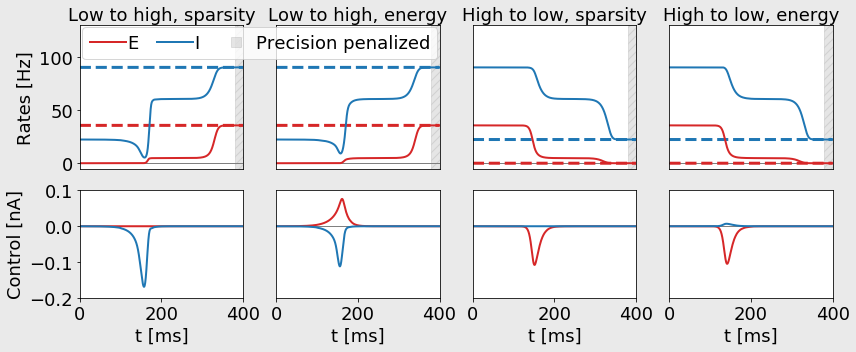

In [14]:
plot_control_current(aln, [opt_cntrl_1, opt_cntrl_2, opt_cntrl_3, opt_cntrl_4],
            [cost_node_1, cost_node_2, cost_node_3, cost_node_4],
            [weights, weights], t_sim, t_sim_pre, t_sim_post,
            [initVars_1, initVars_1, initVars_3, initVars_3], [target_1, target_1, target_3, target_3],
            path_=os.getcwd(), filename_ = 'FIG_3.png', shading = False, transition_time_ = 0.95,
            labels_ = ['Sparsity constraints', 'Energy constraints'],
                    precision_variables_ = [0], print_cost_ = False)
plt.show()

case =  ..\data_final 2
case =  ..\data_final\ 2


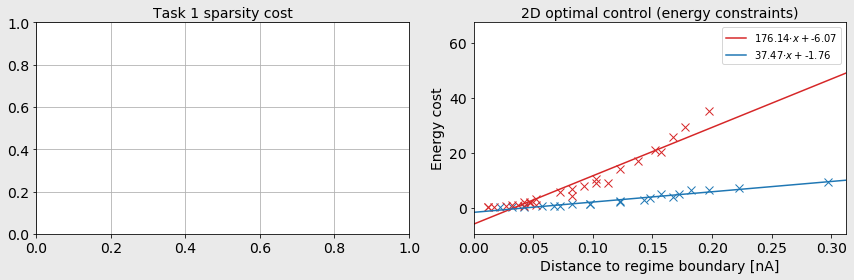

In [15]:
# FIG 16, 18

fig5, ax = plt.subplots(1, 2, figsize = (12,4),facecolor=facecolor_ )
markersize_ = 8

fit_params = np.zeros((2,2,2,2))
    
"""
readcase('1')

fit_d_e = []
fit_d_i = []
fit_c_e = []
fit_c_i = []

for i in range(len(d_e)):
    if type(d_e[i]) != type(None) and cost_s_x[i] > 1e-2:
        fit_d_e.append(d_e[i])
        fit_c_e.append(cost_s_x[i])
        ax[0].plot(d_e[i], cost_s_x[i], marker='x', color=exc_red, markersize=markersize_)
    if type(d_i[i]) != type(None) and cost_s_y[i] > 1e-2:
        fit_d_i.append(d_i[i])
        fit_c_i.append(cost_s_y[i])
        ax[0].plot(d_i[i], cost_s_y[i], marker='x', color=inh_blue, markersize=markersize_)


fit_params[0,0,0,0], fit_params[0,0,0,1] = np.polyfit(fit_d_e, fit_c_e, 1)
fit_params[0,0,1,0], fit_params[0,0,1,1] = np.polyfit(fit_d_i, fit_c_i, 1)

x_ = np.arange(0., max(np.amax(fit_d_e), np.amax(fit_d_i)) + 0.1, 0.001)

ax[0].plot(x_, fit_params[0,0,0,0]*x_ + fit_params[0,0,0,1], color=exc_red,
                  label='{:.2f}'.format(fit_params[0,0,0,0]) + r'$\cdot x + $' + '{:.2f}'.format(fit_params[0,0,0,1]))
ax[0].plot(x_, fit_params[0,0,1,0]*x_ + fit_params[0,0,1,1], color=inh_blue,
                  label='{:.2f}'.format(fit_params[0,0,1,0]) + r'$\cdot x + $' + '{:.2f}'.format(fit_params[0,0,1,1]))

ax[0].set_xlim([0., 1.05 * max(np.amax(fit_d_e), np.amax(fit_d_i))])

ax[0].set_xlabel("Distance to regime boundary [nA]", fontsize=14)
ax[0].set_ylabel("Sparsity cost", fontsize=14)

ax[0].grid(False)
"""

readcase('2')

fit_d_e = []
fit_d_i = []
fit_c_e = []
fit_c_i = []

for i in range(len(d_e)):
    if type(d_e[i]) != type(None):
        if np.abs(a_e[i]) > np.abs(a_i[i]):
            fit_d_e.append(d_e[i])
            fit_c_e.append(cost_e_x[i])
            ax[1].plot(d_e[i], cost_e_x[i], marker='x', color=exc_red, markersize=markersize_)
        elif np.abs(a_e[i]) <= np.abs(a_i[i]):
            fit_d_i.append(d_i[i])
            fit_c_i.append(cost_e_y[i])
            ax[1].plot(d_i[i], cost_e_y[i], marker='x', color=inh_blue, markersize=markersize_)


fit_params[0,0,0,0], fit_params[0,0,0,1] = np.polyfit(fit_d_e, fit_c_e, 1)
fit_params[0,0,1,0], fit_params[0,0,1,1] = np.polyfit(fit_d_i, fit_c_i, 1)

x_ = np.arange(0., max(np.amax(fit_d_e), np.amax(fit_d_i)) + 0.1, 0.001)

ax[1].plot(x_, fit_params[0,0,0,0]*x_ + fit_params[0,0,0,1], color=exc_red,
                  label='{:.2f}'.format(fit_params[0,0,0,0]) + r'$\cdot x + $' + '{:.2f}'.format(fit_params[0,0,0,1]))
ax[1].plot(x_, fit_params[0,0,1,0]*x_ + fit_params[0,0,1,1], color=inh_blue,
                  label='{:.2f}'.format(fit_params[0,0,1,0]) + r'$\cdot x + $' + '{:.2f}'.format(fit_params[0,0,1,1]))

ax[1].set_xlim([0., 1.05 * max(np.amax(fit_d_e), np.amax(fit_d_i))])

ax[1].set_xlabel("Distance to regime boundary [nA]", fontsize=14)
ax[1].set_ylabel("Energy cost", fontsize=14)

ax[1].grid(False)

ax[0].tick_params(axis='x', labelsize=14)
ax[1].tick_params(axis='x', labelsize=14)
ax[0].tick_params(axis='y', labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)

ax[1].legend()

cols = ['Task 1 sparsity cost', '2D optimal control (energy constraints)']
            
for a, col in zip(ax[:], cols):
    a.annotate(col, xy=(0.5, 1.0), xytext=(0,5), xycoords='axes fraction', textcoords='offset points',
               size=14, ha='center', va='baseline')

fig5.tight_layout()

plt.savefig( os.path.join(os.getcwd(), 'FIG_4'), facecolor=fig5.get_facecolor(), edgecolor='none',
            bbox_inches = 'tight', dpi=600)
plt.show()